In [ ]:

import requests


url = 'https://www.alphavantage.co/query?function=DIGITAL_CURRENCY_DAILY&symbol=BTC&market=USD&apikey=IMC7MNTFRJNI2QX2'
r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Daily Prices and Volumes for Digital Currency', '2. Digital Currency Code': 'BTC', '3. Digital Currency Name': 'Bitcoin', '4. Market Code': 'USD', '5. Market Name': 'United States Dollar', '6. Last Refreshed': '2026-04-11 00:00:00', '7. Time Zone': 'UTC'}, 'Time Series (Digital Currency Daily)': {'2026-04-11': {'1. open': '72997.88000000', '2. high': '72997.88000000', '3. low': '72846.65000000', '4. close': '72916.45000000', '5. volume': '52.89758156'}, '2026-04-10': {'1. open': '71798.01000000', '2. high': '73477.87000000', '3. low': '71431.55000000', '4. close': '72997.88000000', '5. volume': '10066.64303661'}, '2026-04-09': {'1. open': '71083.99000000', '2. high': '73147.81000000', '3. low': '70468.74000000', '4. close': '71798.01000000', '5. volume': '10707.78813462'}, '2026-04-08': {'1. open': '71910.21000000', '2. high': '72861.38000000', '3. low': '70684.65000000', '4. close': '71085.99000000', '5. volume': '11083.24086941'}, '2026-04-07': {'1. 

In [ ]:
import pandas as pd
raw= data['Time Series (Digital Currency Daily)']
raw

df = pd.DataFrame(raw).T


df.head()

,1. open,2. high,3. low,4. close,5. volume
2026-04-11,72997.88000000,72997.88000000,72846.65000000,72916.45000000,52.89758156
2026-04-10,71798.01000000,73477.87000000,71431.55000000,72997.88000000,10066.64303661
2026-04-09,71083.99000000,73147.81000000,70468.74000000,71798.01000000,10707.78813462
2026-04-08,71910.21000000,72861.38000000,70684.65000000,71085.99000000,11083.24086941
2026-04-07,68853.60000000,72753.97000000,67710.01000000,71910.20000000,11156.72732306


In [ ]:
df.columns = [
    'open_USD', 'high_USD',
    'low_USD', 'close_USD',
    'volume'
]

df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.isnull().sum()
df = df.astype(float)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5748 entries, 2010-07-17 to 2026-04-11
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open_USD   5748 non-null   float64
 1   high_USD   5748 non-null   float64
 2   low_USD    5748 non-null   float64
 3   close_USD  5748 non-null   float64
 4   volume     5748 non-null   float64
dtypes: float64(5)
memory usage: 269.4 KB


,open_USD,high_USD,low_USD,close_USD,volume
2010-07-17,0.0500,0.0500,0.0500,0.0500,0.000000
2010-07-18,0.0858,0.0858,0.0858,0.0858,0.000000
2010-07-19,0.0808,0.0808,0.0808,0.0808,0.000000
2010-07-20,0.0747,0.0747,0.0747,0.0747,0.000000
2010-07-21,0.0792,0.0792,0.0792,0.0792,0.000000
...,...,...,...,...,...
2026-04-07,68853.6000,72753.9700,67710.0100,71910.2000,11156.727323
2026-04-08,71910.2100,72861.3800,70684.6500,71085.9900,11083.240869
2026-04-09,71083.9900,73147.8100,70468.7400,71798.0100,10707.788135
2026-04-10,71798.0100,73477.8700,71431.5500,72997.8800,10066.643037


In [ ]:
import numpy as np

df['log_return']= np.log(df['close_USD'] / df['close_USD'].shift(1))
df['lag1'] = df['log_return'].shift(1)
df['lag2'] = df['log_return'].shift(2)
df['lag3'] = df['log_return'].shift(3)
df['lag5'] = df['log_return'].shift(5)
df['Target'] = df['log_return'].shift(-1)

df['volatility_7'] = df['log_return'].rolling(7).std()
df['volatility_30'] = df['log_return'].rolling(30).std()

df['log_volume'] = np.log(df['volume'] + 1)
df['volume_change'] = df['log_volume'].diff()

df['high_low_ratio'] = np.log(df['high_USD'] / df['low_USD'])
df['open_close_ratio'] = np.log(df['close_USD'] / df['open_USD'])

df['momentum_3'] = df['close_USD'].pct_change(3)
df['momentum_7'] = df['close_USD'].pct_change(7)




# 1. Find the highest price Bitcoin has hit in the last 30 days
rolling_max = df['close_USD'].rolling(window=30, min_periods=1).max()

# 2. Calculate how far we are below that peak (%)
df['Drawdown'] = (df['close_USD'] - rolling_max) / rolling_max



# --- 1. RSI (Relative Strength Index) ---
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss

    return 100 - (100 / (1 + rs))


df['RSI'] = calculate_rsi(df['close_USD'])
df['RSI_change'] = df['RSI'].diff()
df['RSI_overbought'] = (df['RSI'] > 70).astype(int)
df['RSI_oversold'] = (df['RSI'] < 30).astype(int)



# --- 2. MACD (Moving Average Convergence Divergence) ---
# MACD is the difference between a fast and a slow moving average
exp1 = df['log_return'].ewm(span=12, adjust=False).mean() # 12-day EMA
exp2 = df['log_return'].ewm(span=26, adjust=False).mean() # 26-day EMA
df['MACD'] = exp1 - exp2

# Signal line (9-day EMA of the MACD itself)
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# --- 3. Cleanup ---
# These indicators need 14-26 days of data to start working,
# so we drop the resulting NaN rows at the beginning.


# 1. Middle Band (20-day Moving Average)
df['MA20'] = df['close_USD'].rolling(window=20).mean()

# 2. 20-day Standard Deviation (The "Risk" measure)
df['20STD'] = df['close_USD'].rolling(window=20).std()

# 3. Upper and Lower Bands
df['Upper_Band'] = df['MA20'] + (df['20STD'] * 2)
df['Lower_Band'] = df['MA20'] - (df['20STD'] * 2)

# 4. Feature for the Model: Bollinger %B
# This normalizes the bands into a 0-to-1 scale
df['Bollinger_PercB'] = (df['close_USD'] - df['Lower_Band']) / (df['Upper_Band'] - df['Lower_Band'])

# 5. Clean up the starting NaN values
df.dropna(inplace=True)

df.head()

df.tail()

,open_USD,high_USD,low_USD,close_USD,volume,log_return,lag1,lag2,lag3,lag5,...,RSI_change,RSI_overbought,RSI_oversold,MACD,MACD_Signal,MA20,20STD,Upper_Band,Lower_Band,Bollinger_PercB
2026-04-06,69005.00,70378.48,68332.00,68853.61,11182.353656,-0.002196,0.025142,0.004942,0.000979,-0.001606,...,-12.028498,0,0,0.001732,0.000321,68530.1090,1743.559785,72017.228571,65042.989429,0.546385
2026-04-07,68853.60,72753.97,67710.01,71910.20,11156.727323,0.043435,-0.002196,0.025142,0.004942,-0.018042,...,12.790740,0,0,0.004912,0.001239,68563.3680,1803.391016,72170.150033,64956.585967,0.963964
2026-04-08,71910.21,72861.38,70684.65,71085.99,11083.240869,-0.011528,0.043435,-0.002196,0.025142,0.000979,...,-5.296558,0,0,0.002962,0.001584,68621.7525,1867.333731,72356.419963,64887.085037,0.829914
2026-04-09,71083.99,73147.81,70468.74,71798.01,10707.788135,0.009966,-0.011528,0.043435,-0.002196,0.004942,...,12.136990,0,0,0.003116,0.001890,68686.8025,1956.623851,72600.050202,64773.554798,0.897522
2026-04-10,71798.01,73477.87,71431.55,72997.88,10066.643037,0.016574,0.009966,-0.011528,0.043435,0.025142,...,16.163775,1,0,0.003728,0.002258,68891.0955,2181.731744,73254.558989,64527.632011,0.970588


In [ ]:
import pandas as pd

# Simple Moving Averages
df['ma_7'] = df['close_USD'].rolling(window=7).mean()
df['ma_90'] = df['close_USD'].rolling(window=90).mean()
df['ma_30'] = df['close_USD'].rolling(window=30).mean()

import numpy as np

df['ma_7_ratio'] = np.log(df['close_USD'] / df['ma_7'])
df['ma_90_ratio'] = np.log(df['close_USD'] / df['ma_90'])
df['ma_30_ratio'] = np.log(df['close_USD'] / df['ma_30'])

df['ma_7_slope'] = df['ma_7'].pct_change()
df['ma_90_slope'] = df['ma_90'].pct_change()
df['ma_30_slope'] = df['ma_30'].pct_change()

df['ma_diff'] = np.log(df['ma_7'] / df['ma_30'])
df['ma_diff_ratio'] = np.log(df['ma_7'] / df['ma_90'])

In [ ]:
# EMA calculations
df['ema_12'] = df['close_USD'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close_USD'].ewm(span=26, adjust=False).mean()

# MACD line
df['macd'] = df['ema_12'] - df['ema_26']

# Signal line (EMA of MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# Histogram (momentum strength)
df['macd_hist'] = df['macd'] - df['macd_signal']

df['macd_norm'] = df['macd'] / df['close_USD']
df['macd_signal_norm'] = df['macd_signal'] / df['close_USD']
df['macd_hist_norm'] = df['macd_hist'] / df['close_USD']

df['macd_trend'] = (df['macd'] > df['macd_signal']).astype(int)
df['macd_hist_change'] = df['macd_hist'].diff()

df = df.dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


x= df.drop(columns=['Target', 'close_USD',
                    'open_USD', 'high_USD',
                    'low_USD', 'Upper_Band',
                    'Lower_Band', 'volume', 'MA20', 'ma_7',
                    'ma_90','ma_30', 'macd', 'macd_signal',
                    'macd_hist',
                    'ema_12', 'ema_26', 'macd_signal',
                    '20STD'])

feature_cols= x.columns
y= df['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, shuffle= False)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size= 0.2, shuffle= False)

scaler = StandardScaler()

#scaler.fit(x_train)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val= scaler.transform(x_val)

x

,log_return,lag1,lag2,lag3,lag5,volatility_7,volatility_30,log_volume,volume_change,high_low_ratio,...,ma_7_slope,ma_90_slope,ma_30_slope,ma_diff,ma_diff_ratio,macd_norm,macd_signal_norm,macd_hist_norm,macd_trend,macd_hist_change
2010-11-14,0.010811,0.028668,0.184113,-0.073019,-0.145954,0.176321,0.133160,0.000000,0.000000,0.000000,...,-0.033883,0.022389,0.031501,0.268725,0.830156,0.134502,0.140057,-0.005555,0,0.000269
2010-11-15,-0.039479,0.010811,0.028668,0.184113,0.133531,0.115086,0.133172,0.000000,0.000000,0.000000,...,0.014489,0.020329,0.029346,0.254186,0.824415,0.134766,0.143511,-0.008745,0,-0.000795
2010-11-16,-0.184561,-0.039479,0.010811,0.028668,-0.073019,0.124569,0.138921,0.000000,0.000000,0.000000,...,0.007368,0.015581,0.020632,0.241105,0.816295,0.139212,0.165922,-0.026710,0,-0.003611
2010-11-17,0.030473,-0.184561,-0.039479,0.010811,0.184113,0.112882,0.138860,0.000000,0.000000,0.000000,...,-0.005682,0.016154,0.021300,0.214330,0.794572,0.118509,0.152455,-0.033947,0,-0.001848
2010-11-18,0.152596,0.030473,-0.184561,-0.039479,0.028668,0.122412,0.139822,0.000000,0.000000,0.000000,...,0.025291,0.019706,0.027939,0.211751,0.800034,0.100752,0.124854,-0.024102,0,0.001350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-06,-0.002196,0.025142,0.004942,0.000979,-0.001606,0.014918,0.020790,9.322182,1.076436,0.029509,...,0.004472,-0.003674,0.000767,-0.020583,-0.098531,-0.008263,-0.009616,0.001354,1,96.095434
2026-04-07,0.043435,-0.002196,0.025142,0.004942,-0.018042,0.020335,0.021828,9.319888,-0.002294,0.071849,...,0.007759,-0.002872,0.002856,-0.015705,-0.087926,-0.003130,-0.007992,0.004862,1,256.445523
2026-04-08,-0.011528,0.043435,-0.002196,0.025142,0.000979,0.021395,0.021015,9.313280,-0.006608,0.030330,...,0.006208,-0.002965,0.001273,-0.010789,-0.078768,-0.000265,-0.006521,0.006256,1,95.046039
2026-04-09,0.009966,-0.011528,0.043435,-0.002196,0.004942,0.018557,0.020716,9.278820,-0.034460,0.037313,...,0.010173,-0.002792,0.000880,-0.001546,-0.065851,0.002782,-0.004608,0.007391,1,85.926555


In [ ]:
import numpy as np

# =============================================
# 1. Choose the lookback window (number of past days to use)
# =============================================
lookback = 10   # you can adjust: 5, 10, 15, 20

# =============================================
# 2. Function to create sequences from 2D arrays
# =============================================
def create_sequences(X, y, lookback):
    """
    X: 2D array (samples, features)
    y: 1D array (samples,)
    lookback: number of past time steps to include
    Returns:
        X_seq: 3D array (samples - lookback, lookback, features)
        y_seq: 1D array (samples - lookback,)
    """
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i : i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

# =============================================
# 3. Apply to your existing train, validation, test sets
# =============================================
# Note: x_train, x_val, x_test are already scaled 2D arrays from your code
# y_train, y_val, y_test are the corresponding targets

X_train_seq, y_train_seq = create_sequences(x_train, y_train.values, lookback)
X_val_seq,   y_val_seq   = create_sequences(x_val,   y_val.values,   lookback)
X_test_seq,  y_test_seq  = create_sequences(x_test,  y_test.values,  lookback)

print(f"Train sequences shape: {X_train_seq.shape}")   # (samples - lookback, lookback, n_features)
print(f"Validation sequences shape: {X_val_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

# =============================================
# 4. Build LSTM model
# =============================================
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(lookback, X_train_seq.shape[2])),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# =============================================
# 5. Train the model
# =============================================
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    verbose=1
)

# =============================================
# 6. Evaluate on test set
# =============================================
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Test MAE: {test_mae:.6f}")

Train sequences shape: (3590, 10, 34)
Validation sequences shape: (891, 10, 34)
Test sequences shape: (1116, 10, 34)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0049 - mae: 0.0475 - val_loss: 0.0019 - val_mae: 0.0315
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0029 - mae: 0.0345 - val_loss: 0.0015 - val_mae: 0.0279
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0029 - mae: 0.0327 - val_loss: 0.0015 - val_mae: 0.0276
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - mae: 0.0316 - val_loss: 0.0014 - val_mae: 0.0268
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0028 - mae: 0.0318 - val_loss: 0.0014 - val_mae: 0.0265
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0027 - mae: 0.0315 - val_loss: 0.0014 - val_mae: 0.0265
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0312 - val_loss: 0.0014 - val_mae: 0.0262
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - mae: 0.0315 - val_loss: 0.0014 - val_mae: 0.0268
Epoch 9/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss

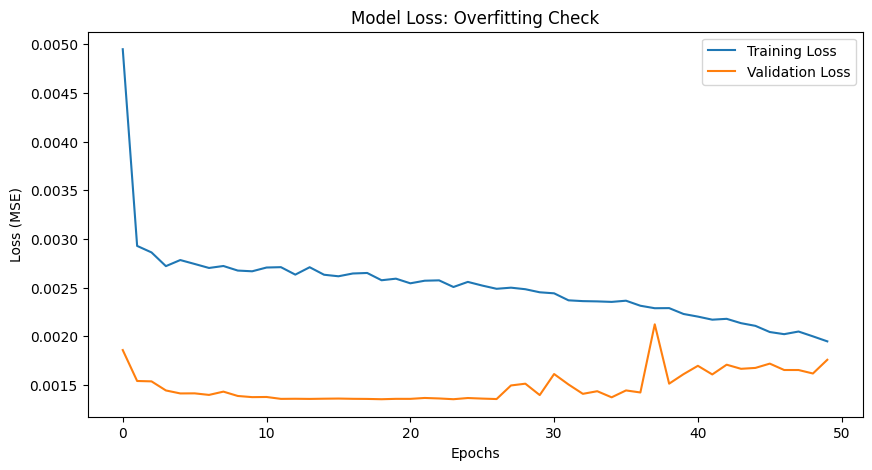

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss: Overfitting Check')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


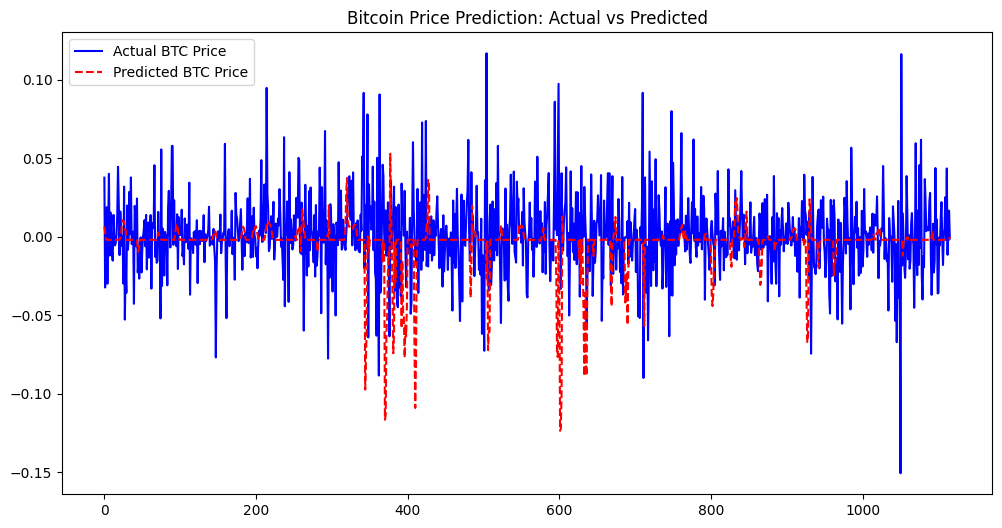

In [ ]:
predictions = model.predict(X_test_seq)

plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label='Actual BTC Price', color='blue')
plt.plot(predictions, label='Predicted BTC Price', color='red', linestyle='--')
plt.title('Bitcoin Price Prediction: Actual vs Predicted')
plt.legend()
plt.show()

In [ ]:

# predictions = model.predict(x_test)

# plt.figure(figsize=(12,6))
# plt.plot(y_test.values, label='Actual BTC Price', color='blue')
# plt.plot(predictions, label='Predicted BTC Price', color='red', linestyle='--')
# plt.title('Bitcoin Price Prediction: Actual vs Predicted')
# plt.legend()
# plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df[feature_cols].corr(numeric_only=True)

# Print it
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Simple baseline: predict yesterday's return
baseline_mae = np.mean(np.abs(y_test - df['log_return'].shift(1).loc[y_test.index]))

# Compare with your linear regression and neural network
print(f"Baseline MAE: {baseline_mae:.6f}")
print(f"NN MAE: {history.history['val_mae'][-1]:.6f}")

Baseline MAE: 0.025504
NN MAE: 0.029014
